AnalystLab Africa Internship Project – Week 1 & 2
Data Cleaning & Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## SECTION 1 ECOMMERCE DATASET

In [2]:
import pandas as pd

df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


# Task 1: Dataset Understanding

This section focuses on understanding the structure, content, and characteristics of the dataset before cleaning and analysis. It helps to identify the data types, shape, and potential issues in the dataset.


## Dataset Overview

The Online Retail dataset contains transactional data from a UK-based online retail store. It includes information about invoices, products, quantities, prices, customers, and countries. The dataset is useful for analyzing sales performance, customer behavior, and revenue trends.


## Dataset Shape

The dataset contains 541,909 rows and 8 columns, representing individual transaction records.

In [6]:
df.shape

(541909, 8)

## Data Types

The dataset contains a mix of numerical and categorical variables:

* Numerical: Quantity, UnitPrice, CustomerID
* Categorical: InvoiceNo, StockCode, Description, InvoiceDate, Country

The InvoiceDate column is currently stored as a string and will be converted to datetime during cleaning.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## Missing Values

The dataset contains missing values in the following columns:

* Description
* CustomerID

These missing values will be addressed during the data cleaning phase.

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Summary of Dataset Understanding

* The dataset contains over half a million transaction records.
* It includes both customer-level and product-level information.
* Some missing values exist in key columns such as CustomerID and Description.
* The dataset is suitable for sales, customer, and product analysis after cleaning.

# Task 2 Explorary Data Analysis (EDA)

In [9]:
import pandas as pd

df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

df_clean = df.copy()
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [10]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values were identified in the dataset. The Description and CustomerID columns contain null values which need to be handled before analysis.

In [11]:
df_clean = df_clean.dropna(subset=['Description'])
df_clean = df_clean.dropna(subset=['CustomerID'])

In [12]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Handling Missing Values (Justification)

Missing values were observed in Description and CustomerID columns.

* The Description column was dropped because product description is essential for identifying items and performing product-level analysis.
* The CustomerID column was also removed because customer-level analysis requires valid identifiers. Although this resulted in a reduction of data size, it ensures accuracy in customer-based insights.

This decision was made to prioritize data quality and analytical reliability over dataset size.

In [13]:
df_clean.duplicated().sum()

np.int64(5225)

In [14]:
df_clean = df_clean.drop_duplicates()

Duplicate records were identified and removed to ensure each transaction is unique and to prevent bias in analysis.

In [15]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

InvoiceDate column was converted from string format to datetime format to enable time-based analysis.

In [16]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

A new Revenue column was created by multiplying Quantity and UnitPrice to support sales analysis.

In [17]:
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

Column names were standardized by converting them to lowercase and replacing spaces with underscores for consistency.

In [18]:
df_clean.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [19]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    401604 non-null  str           
 1   stockcode    401604 non-null  str           
 2   description  401604 non-null  str           
 3   quantity     401604 non-null  int64         
 4   invoicedate  401604 non-null  datetime64[us]
 5   unitprice    401604 non-null  float64       
 6   customerid   401604 non-null  float64       
 7   country      401604 non-null  str           
 8   revenue      401604 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.6 MB


In [20]:
summary = pd.DataFrame({
    "Issue Found": [
        "Missing Values",
        "Duplicate Records",
        "Date Format",
        "Column Names"
    ],
    "Action Taken": [
        "Removed rows with missing Description and CustomerID",
        "Removed duplicate rows",
        "Converted InvoiceDate to datetime",
        "Standardized column names"
    ]
})

summary

,Issue Found,Action Taken
0,Missing Values,Removed rows with missing Description and Cust...
1,Duplicate Records,Removed duplicate rows
2,Date Format,Converted InvoiceDate to datetime
3,Column Names,Standardized column names


The dataset was successfully cleaned by handling missing values, removing duplicates, standardizing column names, and converting data types. The dataset is now ready for exploratory data analysis.

In [21]:
df_clean.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df_clean['revenue'] = df_clean['quantity'] * df_clean['unitprice']

A Revenue column was created to calculate total sales per transaction.

In [23]:
df_clean.describe()

,quantity,invoicedate,unitprice,customerid,revenue
count,401604.000000,401604,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818,20.613638
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,250.283037,NaN,69.764035,1714.006089,430.352218


This provides statistical summary of numerical columns such as Quantity, UnitPrice, and Revenue.

In [24]:
top_products = df_clean.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
top_products

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: quantity, dtype: int64

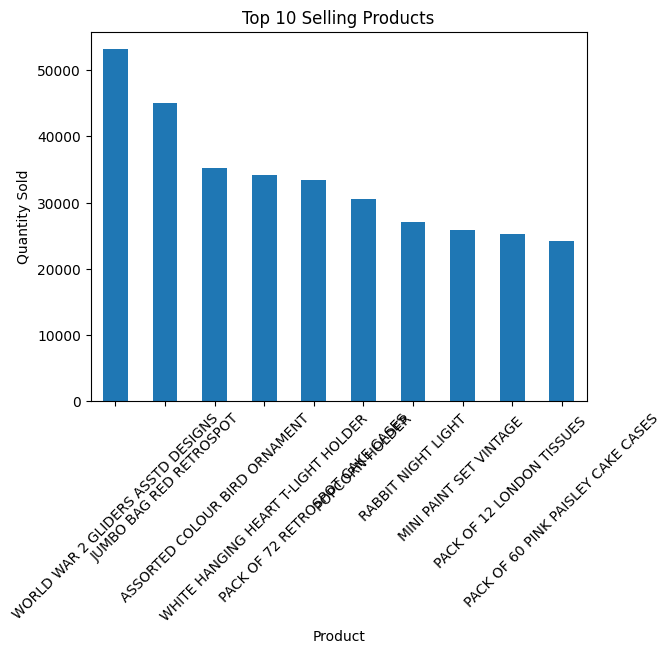

In [25]:
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

The chart shows the top 10 most purchased products based on quantity sold.

In [26]:
top_countries = df_clean.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
top_countries

country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: revenue, dtype: float64

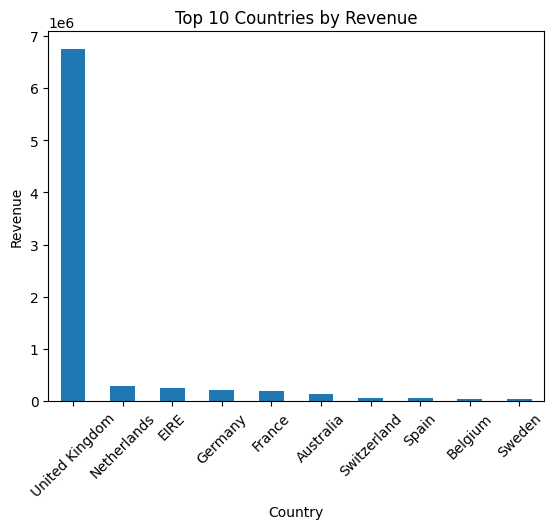

In [27]:
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

The United Kingdom contributes the highest revenue compared to other countries.

In [28]:
df_clean['invoicedate'] = pd.to_datetime(df_clean['invoicedate'])

monthly_sales = df_clean.groupby(df_clean['invoicedate'].dt.to_period('M'))['revenue'].sum()
monthly_sales

invoicedate
2010-12     552372.860
2011-01     473731.900
2011-02     435534.070
2011-03     578576.210
2011-04     425222.671
2011-05     647011.670
2011-06     606862.520
2011-07     573112.321
2011-08     615078.090
2011-09     929356.232
2011-10     973306.380
2011-11    1126815.070
2011-12     341539.430
Freq: M, Name: revenue, dtype: float64

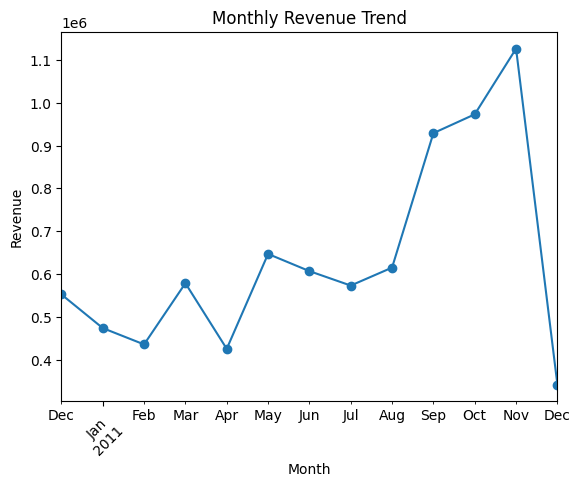

In [29]:
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Revenue shows fluctuations across months, indicating seasonal buying patterns.

In [30]:
top_customers = df_clean.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)
top_customers

customerid
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: revenue, dtype: float64

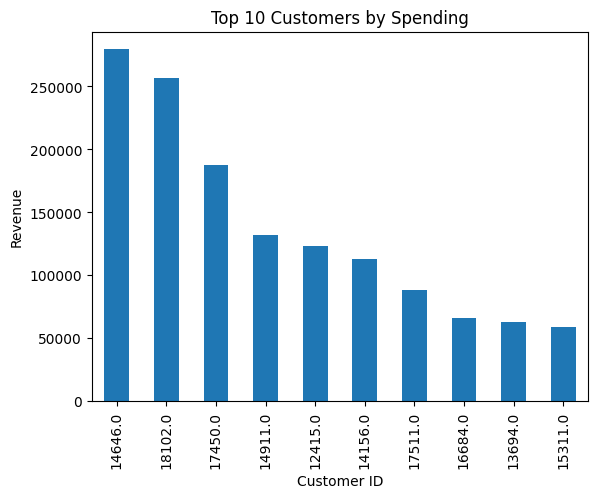

In [31]:
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

A small group of customers contributes significantly to total revenue.

In [32]:
df_clean['description'].value_counts().head(10)

description
WHITE HANGING HEART T-LIGHT HOLDER    2058
REGENCY CAKESTAND 3 TIER              1894
JUMBO BAG RED RETROSPOT               1659
PARTY BUNTING                         1409
ASSORTED COLOUR BIRD ORNAMENT         1405
LUNCH BAG RED RETROSPOT               1345
SET OF 3 CAKE TINS PANTRY DESIGN      1224
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1099
PACK OF 72 RETROSPOT CAKE CASES       1062
Name: count, dtype: int64

Some products appear more frequently in transactions, showing high demand concentration.

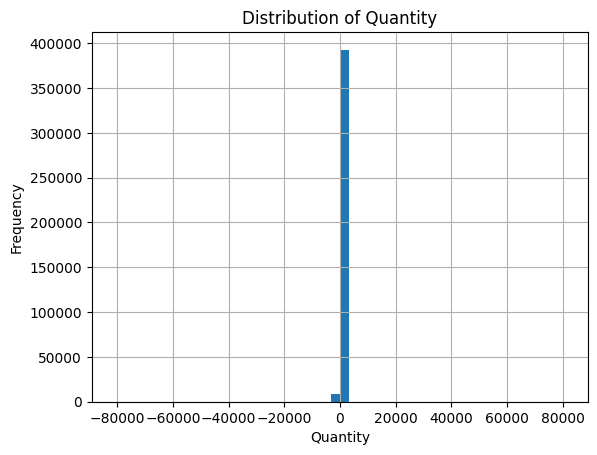

In [33]:
df_clean['quantity'].hist(bins=50)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

The distribution of quantity shows most transactions involve small purchase quantities.

# Key Insights from EDA

1. The United Kingdom is the dominant revenue-generating country.
2. A small number of products generate the majority of sales.
3. Sales show fluctuations over time, indicating seasonal patterns.
4. A small group of customers contributes significantly to total revenue.
5. Demand is concentrated around a few frequently purchased products.


## SECTION 2 NETFLIX DATASET

In [37]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', '_i2', 'df', '_2', '_i3', '_3', '_i4', '_4', '_i5', '_i6', '_6', '_i7', '_i8', '_8', '_i9', 'df_clean', '_9', '_i10', '_10', '_i11', '_i12', '_12', '_i13', '_13', '_i14', '_i15', '_i16', '_i17', '_i18', '_18', '_i19', '_i20', 'summary', '_20', '_i21', '_21', '_i22', '_i23', '_23', '_i24', 'top_products', '_24', '_i25', '_i26', 'top_countries', '_26', '_i27', '_i28', 'monthly_sales', '_28', '_i29', '_i30', 'top_customers', '_30', '_i31', '_i32', '_32', '_i33', '_i34', '_i35', '_i36', '_i37'])

In [38]:
df = pd.read_csv('netflix_titles.csv')

In [39]:
import pandas as pd

netflix = pd.read_csv('netflix_titles.csv')

netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [40]:
netflix_clean = netflix.copy()

In [41]:
netflix_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [42]:
netflix_clean.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [43]:
netflix_clean['director'] = netflix_clean['director'].fillna('Unknown')
netflix_clean['cast'] = netflix_clean['cast'].fillna('Unknown')
netflix_clean['country'] = netflix_clean['country'].fillna('Unknown')
netflix_clean['rating'] = netflix_clean['rating'].fillna('Not Rated')

In [44]:
netflix_clean = netflix_clean.dropna(subset=['date_added'])

Missing values in Director, Cast, Country, and Rating were filled with placeholder values to preserve records. Rows with missing Date Added values were removed because the field is important for time-based analysis.

In [45]:
netflix_clean.duplicated().sum()

np.int64(0)

No duplicate records were identified.

In [47]:
netflix_clean['date_added'].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: str

In [48]:
netflix_clean['date_added'] = netflix_clean['date_added'].str.strip()

In [49]:
netflix_clean['date_added'] = pd.to_datetime(
    netflix_clean['date_added'],
    errors='coerce'
)

In [50]:
netflix_clean['date_added'].isnull().sum()

np.int64(0)

During date conversion, some records contained leading spaces and inconsistent formatting in the date_added column, causing a ValueError. The issue was resolved by trimming whitespace using .str.strip() and converting dates with errors='coerce' before removing invalid records.

In [51]:
netflix_clean.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   str           
 1   type          8797 non-null   str           
 2   title         8797 non-null   str           
 3   director      8797 non-null   str           
 4   cast          8797 non-null   str           
 5   country       8797 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   str           
 9   duration      8794 non-null   str           
 10  listed_in     8797 non-null   str           
 11  description   8797 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 893.4 KB


# Netflix EDA Task 3

In [52]:
netflix_clean['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

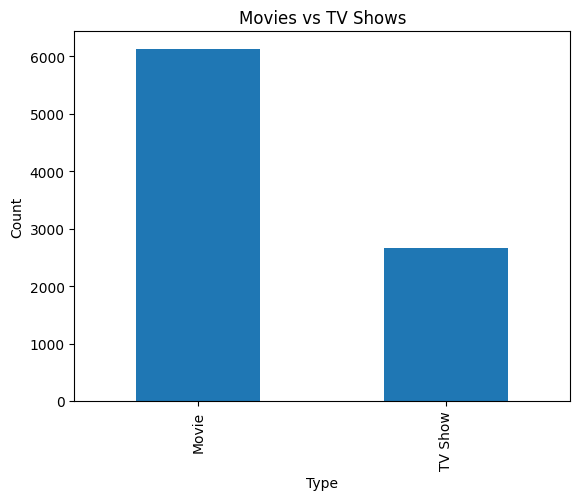

In [53]:
netflix_clean['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [54]:
netflix_clean['year_added'] = netflix_clean['date_added'].dt.year

netflix_clean['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

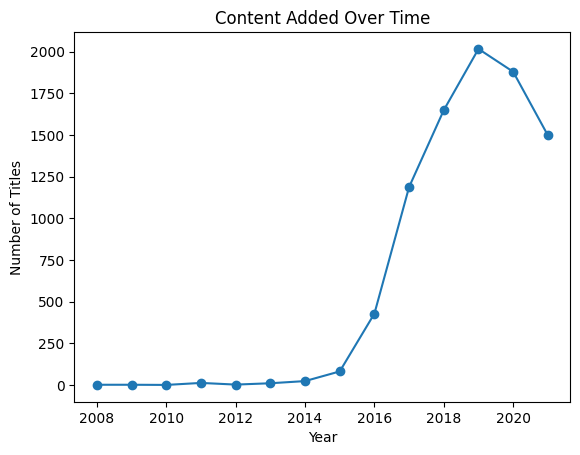

In [55]:
netflix_clean['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [56]:
netflix_clean['country'].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

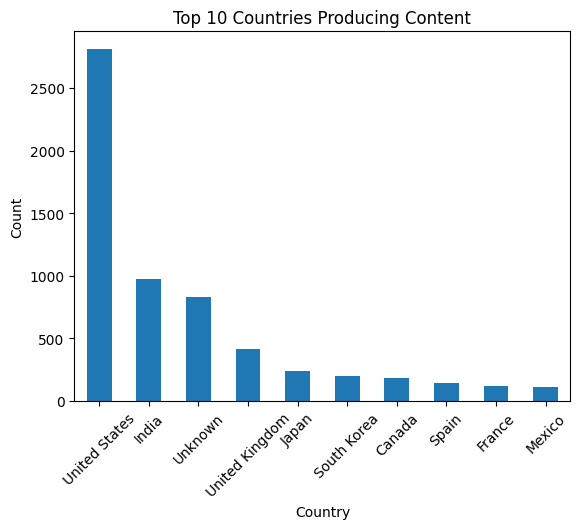

In [57]:
netflix_clean['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [58]:
netflix_clean['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

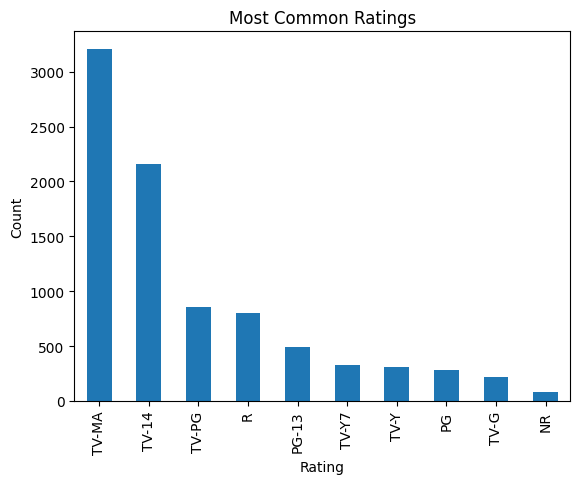

In [59]:
netflix_clean['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Most Common Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [60]:
netflix_clean['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

# Netflix EDA Insights

1. Movies make up a larger portion of Netflix content compared to TV Shows.
2. The number of titles added to Netflix increased significantly in recent years.
3. The United States and India are the leading content-producing countries.
4. TV-MA and TV-14 are the most common content ratings.
5. Drama and International Movies are among the most frequently listed genres.
